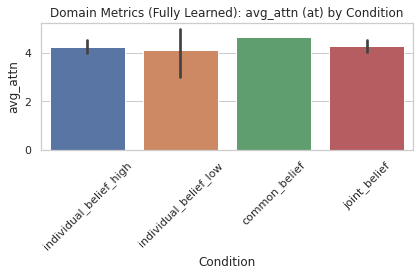

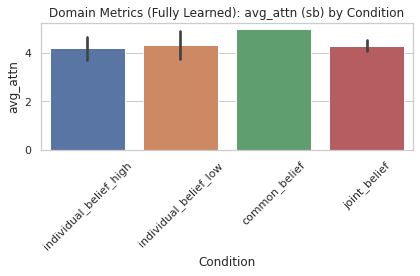

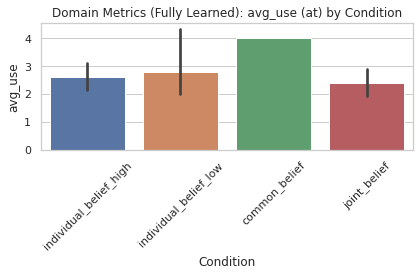

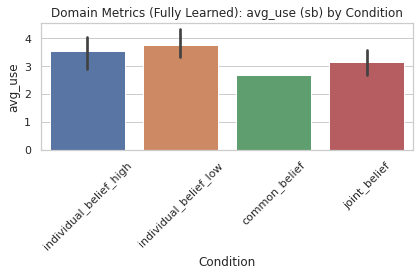

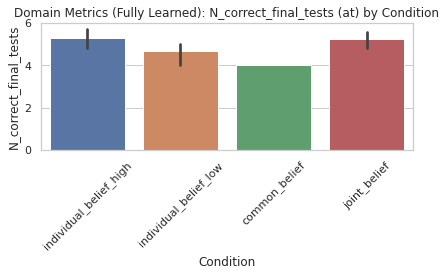

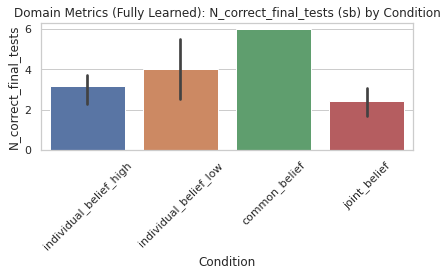

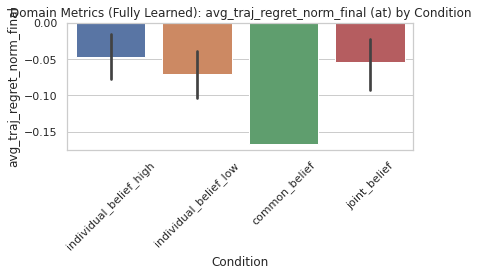

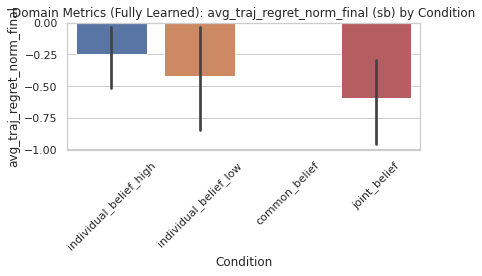

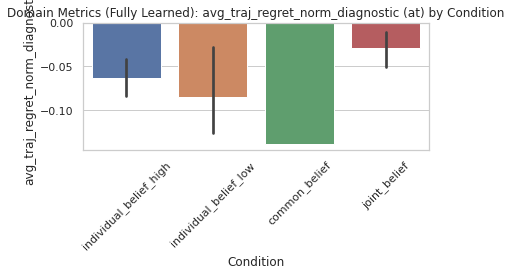

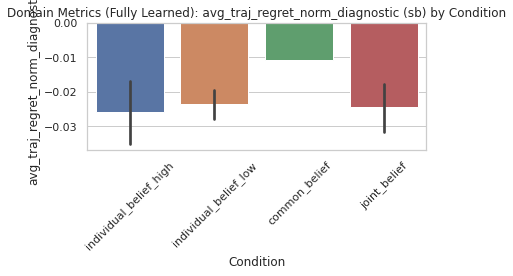

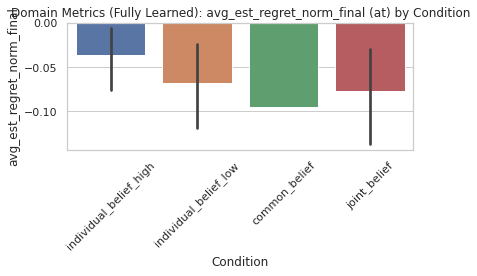

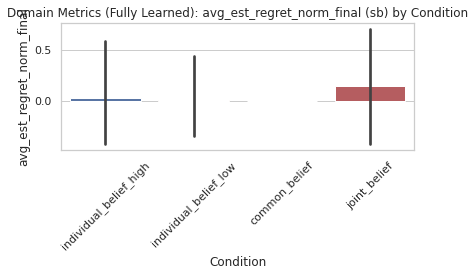

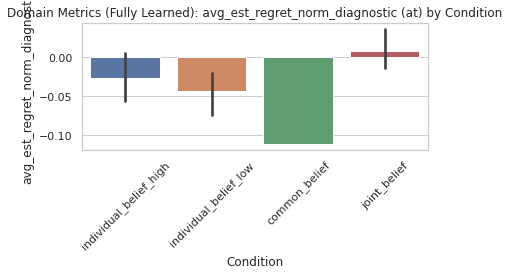

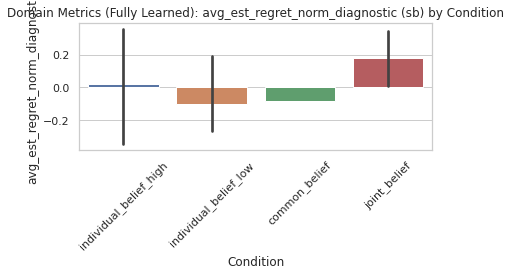

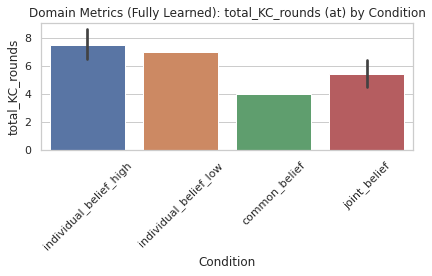

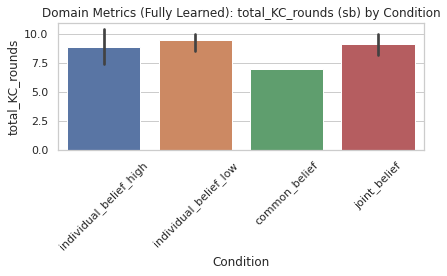

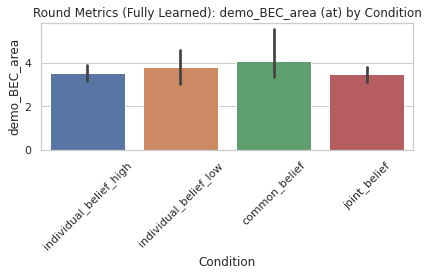

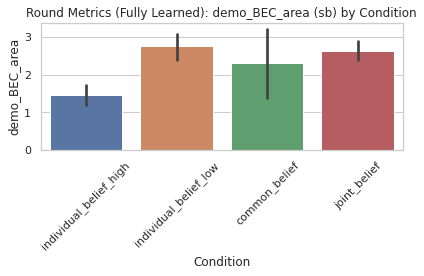

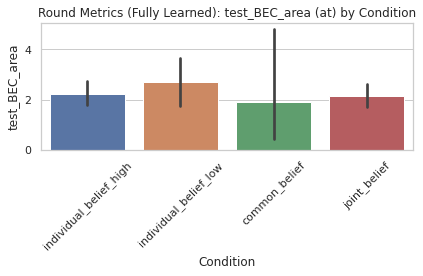

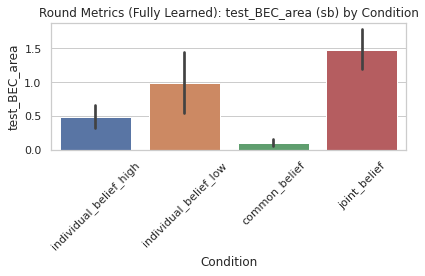

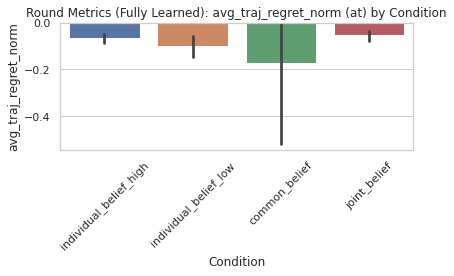

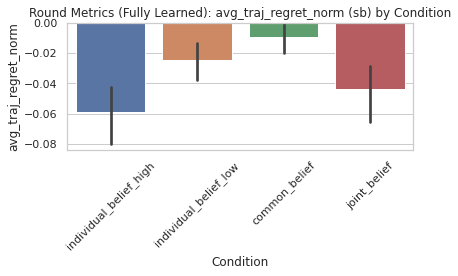

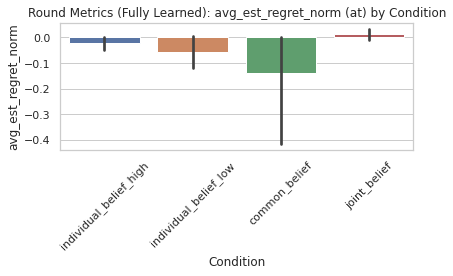

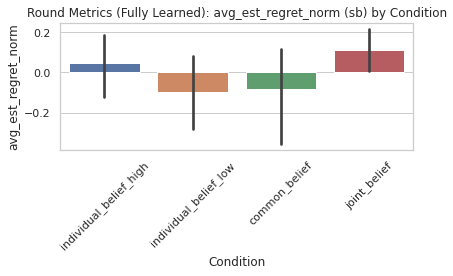

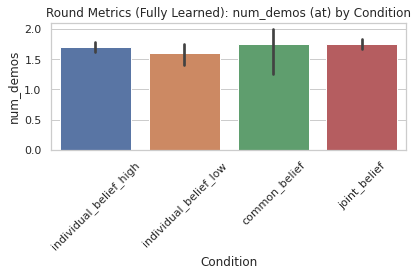

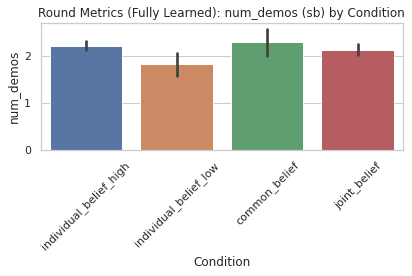

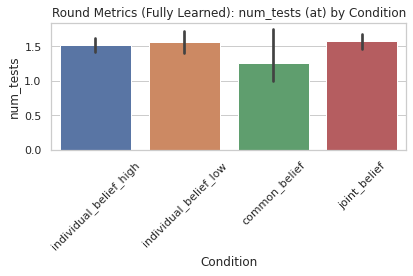

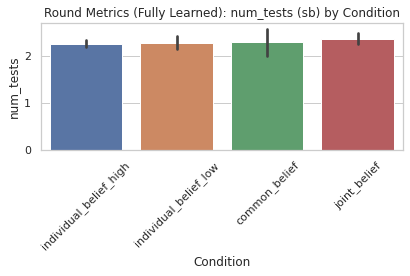

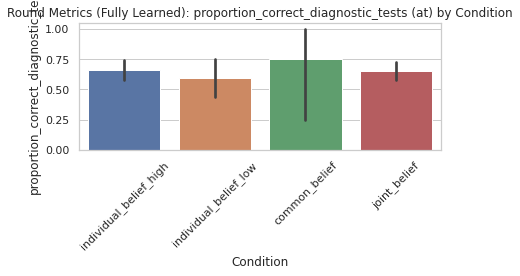

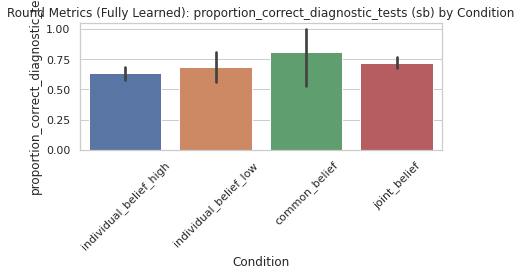

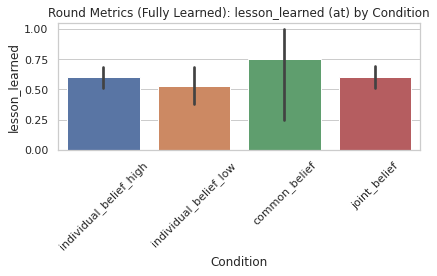

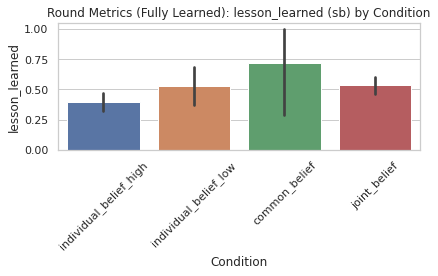

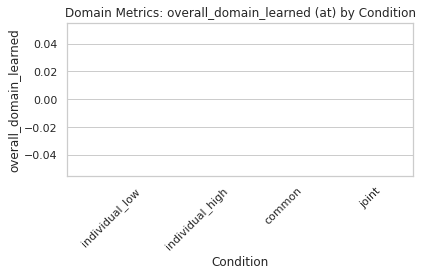

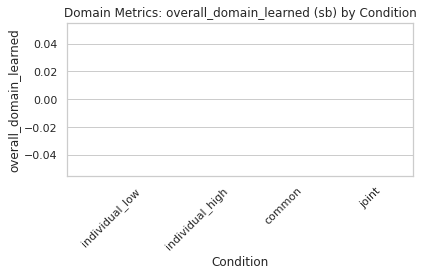

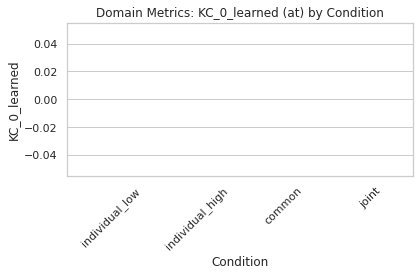

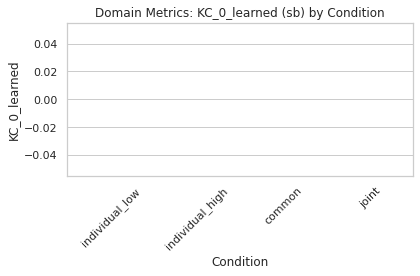

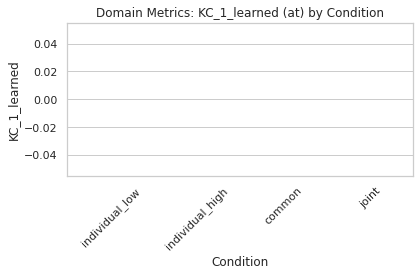

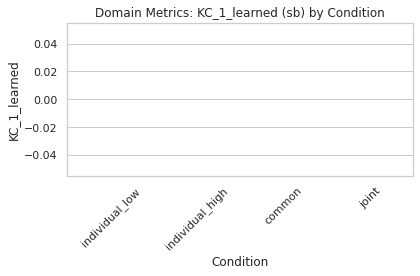

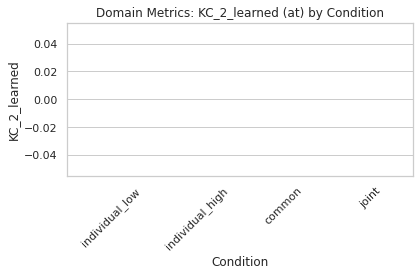

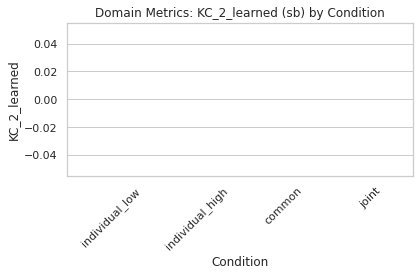

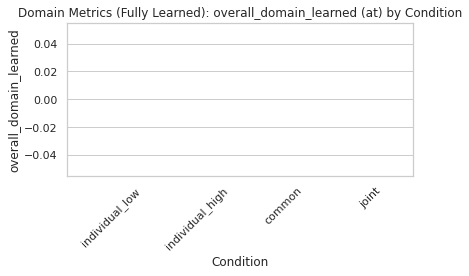

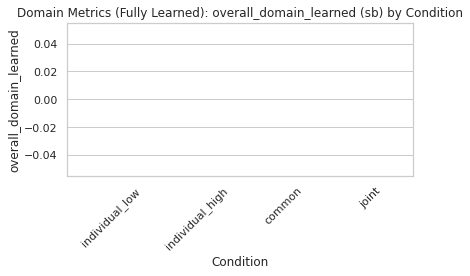

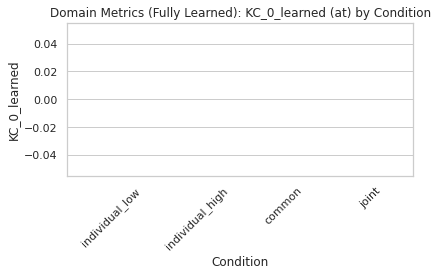

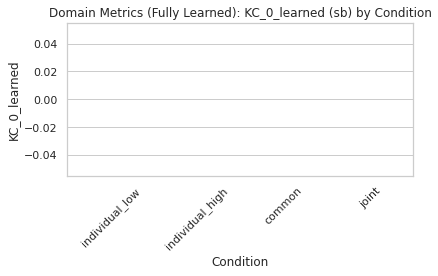

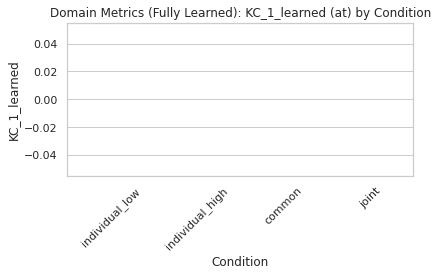

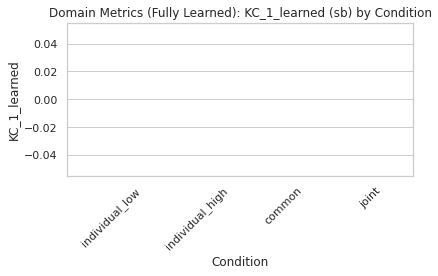

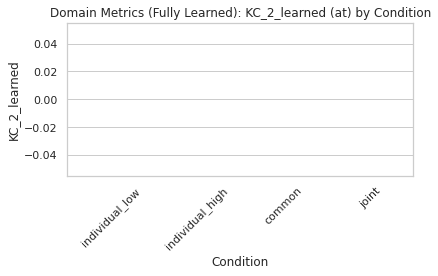

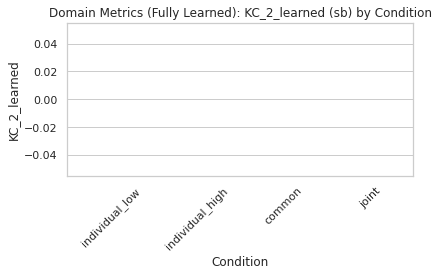

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid")

# Load data
domain_df = pd.read_excel("../results/domain_df_w_metrics.xlsx")

domain_df_learned = domain_df[domain_df['overall_domain_learned'] == 1]
users_learned = domain_df_learned['user_id'].unique()


string_cols = ['domain', 'domain_name', 'experimental_condition', 'domain_order', 'user_id', 'group_id']

# Ensure string columns are string
for col in string_cols:
    if col in domain_df.columns:
        domain_df[col] = domain_df[col].astype(str)

round_df = pd.read_excel("../results/round_df_w_metrics.xlsx")
round_df_learned = round_df[round_df['user_id'].isin(users_learned)]


# string_cols = ['domain', 'domain_name', 'experimental_condition', 'domain_order', 'user_id', 'group_id']

# Order settings
condition_order = ['individual_low', 'individual_high', 'common', 'joint']
domain_order = ['augmented_taxi2', 'skateboard2']


# Dependent variables
domain_vars = ['avg_attn', 'avg_use', 'N_correct_final_tests',
               'avg_traj_regret_norm_final', 'avg_traj_regret_norm_diagnostic',
               'avg_est_regret_norm_final', 'avg_est_regret_norm_diagnostic', 'total_KC_rounds']

round_vars = ['demo_BEC_area', 'test_BEC_area', 'avg_traj_regret_norm',
              'avg_est_regret_norm', 'num_demos', 'num_tests',
              'proportion_correct_diagnostic_tests', 'lesson_learned']

domain_vars_boolean = ['overall_domain_learned', 'KC_0_learned', 'KC_1_learned', 'KC_2_learned']

traj_regret_vars = ['avg_traj_regret_norm_final', 'avg_traj_regret_norm_diagnostic', 'avg_traj_regret_norm']
est_regret_vars = ['avg_est_regret_norm_final', 'avg_est_regret_norm_diagnostic', 'avg_est_regret_norm']

# Binning for regret variables
combined_traj_regret = pd.concat([
    domain_df['avg_traj_regret_norm_final'],
    domain_df['avg_traj_regret_norm_diagnostic'],
    round_df['avg_traj_regret_norm']
])
combined_est_regret = pd.concat([
    domain_df['avg_est_regret_norm_final'],
    domain_df['avg_est_regret_norm_diagnostic'],
    round_df['avg_est_regret_norm']
])

traj_bins = np.array(np.histogram_bin_edges(combined_traj_regret.dropna(), bins=15))
est_bins = np.array(np.histogram_bin_edges(combined_est_regret.dropna(), bins=15))

# Scale factor
scale_factor = 240 / len(domain_df)

# Check discreteness
def is_discrete(series):
    return pd.api.types.is_integer_dtype(series) or series.nunique() < 4

# 1. Overall histograms
def plot_overall_histograms(df, variables, title_prefix):
    for var in variables:
        data = df[var].dropna()
        weights = np.ones_like(data) * scale_factor
        discrete = is_discrete(data)
        print(f"Variable: {var}, Discrete: {discrete}")

        bins = None
        if var in traj_regret_vars:
            bins = traj_bins
        elif var in est_regret_vars:
            bins = est_bins

        df_plot = pd.DataFrame({var: data, "weights": weights})

        plt.figure(figsize=(6, 4))
        if bins is not None:
            sns.histplot(
                data=df_plot,
                x=var,
                weights="weights",
                discrete=discrete,
                bins=bins,
                palette="muted"
            )
        else:
            sns.histplot(
            data=df_plot,
            x=var,
            weights="weights",
            discrete=discrete,
            palette="muted"
        )
        plt.title(f"{title_prefix}: {var}")
        plt.xlabel(var)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

# plot_overall_histograms(domain_df, domain_vars, "Domain Metrics")
# plot_overall_histograms(round_df, round_vars, "Round Metrics")


# 2. Histograms split by domain
def plot_histograms_by_domain(df, variables, title_prefix):
    df = df.copy()
    df['weights'] = scale_factor  # ensure scale_factor is defined externally

    domain_col = 'domain_name' if 'domain_name' in df.columns else 'domain'
    print(f"Plotting by domain column: {domain_col}, domains: {df[domain_col].unique()}")

    for var in variables:
        print(f"\n--- Variable: {var} ---")

        discrete = is_discrete(df[var])

        bins = None
        if var in traj_regret_vars:
            bins = traj_bins
        elif var in est_regret_vars:
            bins = est_bins

        g = sns.FacetGrid(df, col=domain_col, margin_titles=True,
                          height=4, aspect=1.2, sharey=False)

        plot_args = dict(x=var, weights='weights', discrete=discrete,
                         color=sns.color_palette("muted")[0], stat='count')

        if bins is not None:
            plot_args['bins'] = bins

        g.map_dataframe(sns.histplot, **plot_args)
        g.set_axis_labels(var, "Count")
        g.fig.subplots_adjust(top=0.85)
        g.fig.suptitle(f"{title_prefix}: {var}", fontsize=14)

        plt.tight_layout()
        plt.show()


# print('Domain df:', type(domain_df['domain_name'].iloc[0]))
# plot_histograms_by_domain(domain_df, domain_vars, "Domain Metrics")
# plot_histograms_by_domain(round_df, round_vars, "Round Metrics")



# 3. Histograms by domain and condition
def plot_histograms_by_domain_condition(df, variables, title_prefix):
    df = df.copy()
    df['weights'] = scale_factor
    for var in variables:
        discrete = is_discrete(df[var])

        bins = None
        if var in traj_regret_vars:
            bins = traj_bins
        elif var in est_regret_vars:
            bins = est_bins

        domain_col = 'domain_name' if 'domain_name' in df.columns else 'domain'

        g = sns.FacetGrid(df, col=domain_col, row="experimental_condition",
                          margin_titles=True, height=3, aspect=1.2)
        if bins is not None:
            g.map_dataframe(
                sns.histplot,
                x=var,
                weights='weights',
                discrete=discrete,
                bins=bins,
                color=sns.color_palette("muted")[0]
            )
        else:
            g.map_dataframe(
                sns.histplot,
                x=var,
                weights='weights',
                discrete=discrete,
                color=sns.color_palette("muted")[0]
            )
        g.fig.suptitle(f"{title_prefix}: {var}", y=1.02)
        for ax in g.axes.flat:
            ax.set_ylabel("Count")
        plt.tight_layout()
        plt.show()


# plot_histograms_by_domain_condition(domain_df, domain_vars, "Domain Metrics")
# plot_histograms_by_domain_condition(round_df, round_vars, "Round Metrics")


# 4. Bar plots with error bars by condition
def plot_bar_with_error(df, variables, title_prefix):
    domain_col = 'domain_name' if 'domain_name' in df.columns else 'domain'
    unique_domains = df[domain_col].unique()

    for var in variables:
        for domain in unique_domains:
            df_subset = df[(df[domain_col] == domain)]
            plt.figure(figsize=(6, 4))
            # sns.barplot(data=df_subset, x="experimental_condition", y=var, order=condition_order,
            #             errorbar='se')
            sns.barplot(data=df_subset, x="experimental_condition", y=var)
            plt.title(f"{title_prefix}: {var} ({domain}) by Condition") 
            plt.xticks(rotation=45)
            plt.xlabel("Condition")
            plt.ylabel(var)
            plt.tight_layout()
            plt.show()

# plot_bar_with_error(domain_df, domain_vars, "Domain Metrics")
# plot_bar_with_error(round_df, round_vars, "Round Metrics")

plot_bar_with_error(domain_df_learned, domain_vars, "Domain Metrics (Fully Learned)")
plot_bar_with_error(round_df_learned, round_vars, "Round Metrics (Fully Learned)")



def plot_bar_charts_boolean(df, variables, title_prefix):
    domain_col = 'domain_name' if 'domain_name' in df.columns else 'domain'
    unique_domains = df[domain_col].unique()

    for var in variables:
        for domain in unique_domains:
            df_subset = df[(df[domain_col] == domain)]
            plt.figure(figsize=(6, 4))
            sns.barplot(data=df_subset, x="experimental_condition", y=var, order=condition_order)
            plt.title(f"{title_prefix}: {var} ({domain}) by Condition")
            plt.xticks(rotation=45)
            plt.xlabel("Condition")
            plt.ylabel(var)
            plt.tight_layout()
            plt.show()

plot_bar_charts_boolean(domain_df, domain_vars_boolean, "Domain Metrics")
plot_bar_charts_boolean(domain_df_learned, domain_vars_boolean, "Domain Metrics (Fully Learned)")